<a href="https://colab.research.google.com/github/worldstar0722/IS_Research_2025/blob/main/sp500_research_pipeline_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S&P 500 Research ML Pipeline — Ellie and AI
**3-Model Ensemble (LightGBM + RandomForest + GradientBoosting) · Optuna · FinBERT Sentiment · GitHub Pages**

| Setting | Value |
|---------|-------|
| Tickers | Full S&P 500 (~503) |
| Features | 35 technical indicators + per-day FinBERT sentiment (7 features) |
| Models | LightGBM + RandomForest + GradientBoosting → weighted ensemble |
| Tuning | Optuna hyperparameter optimization |
| Output | Auto-push to GitHub Pages + QR code |

### Key Fixes (vs previous version)
1. **Data leakage removed** — sentiment scores are mapped per date, not broadcast across all rows
2. **VADER → FinBERT** — finance-specific sentiment model (GPU accelerated)
3. **GitHub token via Secrets** — token never stored in code

### Quick Start
1. Runtime → Change runtime type → **T4 GPU** + **High-RAM**
2. Add `GITHUB_TOKEN` to Colab Secrets (key icon in left sidebar)
3. Set `GITHUB_USERNAME` and `GITHUB_REPO` in Section 2
4. Run all (Ctrl+F9)

## Section 1 — Install Dependencies

In [1]:
!pip install -q yfinance lightgbm scikit-learn pandas numpy tqdm matplotlib \
    joblib "qrcode[pil]" requests feedparser \
    beautifulsoup4 lxml ta optuna transformers torch accelerate
print("Dependencies installed.")

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
Dependencies installed.


## Section 2 — Configuration  ← EDIT BEFORE RUNNING

In [2]:
# --- GitHub (token stored in Colab Secrets, not in code) ---
from google.colab import userdata
GITHUB_TOKEN    = userdata.get('GITHUB_TOKEN')  # Add via left sidebar → key icon → Secrets
GITHUB_USERNAME = "worldstar0722"
GITHUB_REPO     = "IS_Research_2025"

# --- Scope ---
TEST_COUNT   = None    # None = full S&P 500 (~503) | int = quick test (e.g. 10)

# --- Date range ---
TRAIN_YEARS  = 5
CUTOFF_DATE  = "2025-12-01"  # before = train, after = test

# --- News / Sentiment ---
USE_NEWS       = True   # True = FinBERT sentiment (recommended)
NEWS_BACK_DAYS = 14     # rolling window size (days)
MAX_NEWS_ITEMS = 10     # articles per ticker (10 = fast, 30 = thorough)
NEWS_SLEEP     = 0.1    # seconds between requests (0.1 = fast, 0.3 = safe)

# --- Model ---
RANDOM_STATE   = 42
USE_OPTUNA     = True
OPTUNA_TRIALS  = 5      # trials per model (5 = fast, 20 = thorough)

# ================================================================
import os, json, time, base64, warnings, logging, urllib.parse
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, log_loss)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import joblib, requests, feedparser
from tqdm.notebook import tqdm
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.WARNING)

TODAY  = datetime.today().strftime("%Y-%m-%d")
START  = (datetime.today() - timedelta(days=365 * TRAIN_YEARS)).strftime("%Y-%m-%d")
END    = TODAY
DOCS   = Path("docs");        DOCS.mkdir(exist_ok=True)
PDIR   = Path("predictions"); PDIR.mkdir(exist_ok=True)
MDIR   = Path("models");      MDIR.mkdir(exist_ok=True)

print(f"Config ready  |  {START} → {END}")
print(f"USE_NEWS={USE_NEWS}  |  USE_OPTUNA={USE_OPTUNA}  |  TRIALS={OPTUNA_TRIALS}")
print(f"GitHub Pages: https://{GITHUB_USERNAME}.github.io/{GITHUB_REPO}")

Config ready  |  2021-03-20 → 2026-03-19
USE_NEWS=True  |  USE_OPTUNA=True  |  TRIALS=5
GitHub Pages: https://worldstar0722.github.io/IS_Research_2025


## Section 3 — Load FinBERT (Auto GPU Detection)

In [3]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

FINBERT_MODEL     = None
FINBERT_TOKENIZER = None

if USE_NEWS:
    print("Loading FinBERT (ProsusAI/finbert)...")
    FINBERT_TOKENIZER = BertTokenizer.from_pretrained("ProsusAI/finbert")
    FINBERT_MODEL     = BertForSequenceClassification.from_pretrained("ProsusAI/finbert")
    FINBERT_MODEL     = FINBERT_MODEL.to(DEVICE)
    FINBERT_MODEL.eval()
    print("FinBERT ready.")
else:
    print("News OFF — skipping FinBERT.")

Device: cuda
Loading FinBERT (ProsusAI/finbert)...


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT ready.


## Section 4 — Load S&P 500 Ticker List

In [4]:
def get_sp500() -> List[Tuple[str, str]]:
    """Fetch (symbol, company_name) pairs from Wikipedia."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    try:
        r  = requests.get(url, headers={"User-Agent": "Mozilla/5.0"}, timeout=20)
        df = pd.read_html(r.text)[0]
        syms  = df["Symbol"].str.replace(".", "-", regex=False).tolist()
        names = df.get("Security", pd.Series(syms)).tolist()
        return list(zip(syms, names))
    except Exception as e:
        print(f"Wikipedia failed ({e}) — using fallback list")
        fallback = [
            "AAPL","MSFT","NVDA","AMZN","GOOGL","META","TSLA","BRK-B","JPM","V",
            "WMT","XOM","UNH","MA","HD","LLY","CVX","ABBV","PG","BAC","MRK",
            "COST","AVGO","PEP","KO","CSCO","TMO","ACN","MCD","ABT","ADBE",
            "CRM","NFLX","AMD","TXN","DHR","QCOM","NKE","LOW","INTU",
        ]
        return [(t, t) for t in fallback]

ALL_TICKERS = get_sp500()
if TEST_COUNT:
    ALL_TICKERS = ALL_TICKERS[:TEST_COUNT]
    print(f"TEST mode: {TEST_COUNT} tickers")
else:
    print(f"Full S&P 500: {len(ALL_TICKERS)} tickers")

TICKER_NAME = dict(ALL_TICKERS)

Full S&P 500: 503 tickers


## Section 5 — Feature Engineering (35 Technical Indicators)

In [5]:
def _rsi(s: pd.Series, period: int = 14) -> pd.Series:
    d = s.diff()
    g = d.clip(lower=0).ewm(com=period-1, min_periods=period).mean()
    l = (-d.clip(upper=0)).ewm(com=period-1, min_periods=period).mean()
    return 100 - 100 / (1 + g / l.replace(0, np.nan))

def _macd(s: pd.Series, fast=12, slow=26, sig=9):
    ef = s.ewm(span=fast, min_periods=fast).mean()
    es = s.ewm(span=slow, min_periods=slow).mean()
    line = ef - es
    signal = line.ewm(span=sig, min_periods=sig).mean()
    return line, signal, line - signal

def _stoch_rsi(s: pd.Series, period=14, smooth=3) -> pd.Series:
    rsi = _rsi(s, period)
    lo  = rsi.rolling(period).min()
    hi  = rsi.rolling(period).max()
    return ((rsi - lo) / (hi - lo + 1e-9)).rolling(smooth).mean()

def _williams_r(high, low, close, period=14) -> pd.Series:
    hh = high.rolling(period).max()
    ll = low.rolling(period).min()
    return -100 * (hh - close) / (hh - ll + 1e-9)

def _atr(high, low, close, period=14) -> pd.Series:
    tr = pd.concat([
        high - low,
        (high - close.shift()).abs(),
        (low  - close.shift()).abs(),
    ], axis=1).max(axis=1)
    return tr.ewm(com=period-1, min_periods=period).mean()

def _obv(close, volume) -> pd.Series:
    return (np.sign(close.diff()).fillna(0) * volume).cumsum()

def featurize(df: pd.DataFrame, ticker: str) -> Optional[pd.DataFrame]:
    """Build 35 technical features + binary label. Sentiment added separately."""
    try:
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        close  = df["Close"].squeeze().astype(float)
        high   = df["High"].squeeze().astype(float)   if "High"   in df.columns else close
        low    = df["Low"].squeeze().astype(float)    if "Low"    in df.columns else close
        open_  = df["Open"].squeeze().astype(float)   if "Open"   in df.columns else close
        volume = df["Volume"].squeeze().astype(float) if "Volume" in df.columns else pd.Series(1e6, index=df.index)

        out = pd.DataFrame(index=df.index)
        ret = close.pct_change()

        # Lagged returns
        for lag in [1, 2, 3, 5, 10]:
            out[f"ret_{lag}"] = ret.shift(lag)

        # Moving averages
        for w in [5, 10, 20, 50]:
            out[f"ma{w}"] = close.rolling(w).mean()
        out["ma5_20"]  = out["ma5"]  / (out["ma20"] + 1e-9) - 1
        out["ma10_50"] = out["ma10"] / (out["ma50"] + 1e-9) - 1
        out["p_ma20"]  = close / (out["ma20"] + 1e-9) - 1

        # Volatility
        out["vol5"]      = ret.rolling(5).std()
        out["vol20"]     = ret.rolling(20).std()
        out["vol_ratio"] = out["vol5"] / (out["vol20"] + 1e-9)

        # Momentum
        out["mom5"]  = close / close.shift(5)  - 1
        out["mom10"] = close / close.shift(10) - 1
        out["mom20"] = close / close.shift(20) - 1

        # RSI + Stochastic RSI
        out["rsi"]       = _rsi(close)
        out["stoch_rsi"] = _stoch_rsi(close)

        # MACD
        out["macd"], out["macd_sig"], out["macd_hist"] = _macd(close)

        # Bollinger Bands
        bb_ma  = close.rolling(20).mean()
        bb_std = close.rolling(20).std()
        out["bb_w"]   = (2 * bb_std) / (bb_ma + 1e-9)
        out["bb_pct"] = (close - (bb_ma - 2*bb_std)) / (4*bb_std + 1e-9)

        # ATR
        out["atr"]     = _atr(high, low, close)
        out["atr_pct"] = out["atr"] / (close + 1e-9)

        # Williams %R
        out["willr"] = _williams_r(high, low, close)

        # Volume features
        vol_ma5 = volume.rolling(5).mean()
        out["vol_chg"]    = volume.pct_change()
        out["vol_ma_rat"] = volume / (vol_ma5 + 1e-9)
        out["obv_ret"]    = _obv(close, volume).pct_change(5)

        # Candlestick shape
        out["hl_spread"]  = (high - low)   / (close + 1e-9)
        out["body"]       = abs(close - open_) / (close + 1e-9)
        out["upper_wick"] = (high - pd.concat([close, open_], axis=1).max(axis=1)) / (close + 1e-9)
        out["lower_wick"] = (pd.concat([close, open_], axis=1).min(axis=1) - low)  / (close + 1e-9)

        # Label: 1 = next-day close higher than today
        out["label"]    = (close.shift(-1) > close).astype(int)
        out["close_px"] = close
        out["ticker"]   = ticker

        out = out.replace([np.inf, -np.inf], np.nan)
        return out.dropna().iloc[:-1]  # drop last row (no label available)

    except Exception:
        return None

PRICE_FEATURES = [
    "ret_1","ret_2","ret_3","ret_5","ret_10",
    "ma5","ma10","ma20","ma50","ma5_20","ma10_50","p_ma20",
    "vol5","vol20","vol_ratio","mom5","mom10","mom20",
    "rsi","stoch_rsi","macd","macd_sig","macd_hist",
    "bb_w","bb_pct","atr","atr_pct","willr",
    "vol_chg","vol_ma_rat","obv_ret",
    "hl_spread","body","upper_wick","lower_wick",
]
print(f"Technical features: {len(PRICE_FEATURES)}")

Technical features: 35


## Section 6 — FinBERT Sentiment (Per-Date Mapping)

**Key fix**: News headlines are collected with publication dates and mapped to each price row by date.
Each row uses only headlines from the past N days *before* that date — no data leakage.

In [6]:
def _build_session():
    s = requests.Session()
    from requests.adapters import HTTPAdapter
    from urllib3.util.retry import Retry
    retry = Retry(total=3, backoff_factor=1.0, status_forcelist=[429,500,502,503,504])
    s.mount("https://", HTTPAdapter(max_retries=retry))
    s.mount("http://",  HTTPAdapter(max_retries=retry))
    s.headers.update({"User-Agent": "Mozilla/5.0 (StockResearch/1.0)"})
    return s

_session = _build_session()


def fetch_headlines_with_dates(query: str, max_items: int = 10,
                                sleep_s: float = 0.1) -> List[Dict]:
    """Fetch headlines + publication dates from Google News RSS."""
    encoded = urllib.parse.quote_plus(query)
    url = f"https://news.google.com/rss/search?q={encoded}&hl=en-US&gl=US&ceid=US:en"
    for attempt in range(3):
        try:
            time.sleep(sleep_s)
            feed = feedparser.parse(url)
            if not feed.entries:
                return []
            results = []
            for e in feed.entries[:max_items]:
                title = e.get("title", "")
                pub   = e.get("published", "")
                if title and pub:
                    dt = pd.to_datetime(pub, errors="coerce", utc=True)
                    if pd.notna(dt):
                        results.append({"title": title, "date": dt.date()})
            return results
        except Exception:
            time.sleep(2 ** attempt)
    return []


@torch.no_grad()
def finbert_score_batch(texts: List[str], batch_size: int = 16) -> List[float]:
    """
    Run FinBERT on a list of texts in batches.
    Returns compound score: P(positive) - P(negative) for each text.
    """
    if not texts or FINBERT_MODEL is None:
        return [0.0] * len(texts)

    scores = []
    for i in range(0, len(texts), batch_size):
        batch  = texts[i:i+batch_size]
        inputs = FINBERT_TOKENIZER(
            batch,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=128,
        ).to(DEVICE)
        logits   = FINBERT_MODEL(**inputs).logits
        probs    = torch.softmax(logits, dim=1).cpu().numpy()  # [positive, negative, neutral]
        compound = probs[:, 0] - probs[:, 1]                   # positive - negative
        scores.extend(compound.tolist())
    return scores


def build_sentiment_series(headlines: List[Dict],
                            date_index: pd.DatetimeIndex,
                            back_days: int = 14) -> pd.DataFrame:
    """
    Core function: compute rolling sentiment features for each date in date_index.

    For each date t, aggregates headlines from [t - back_days, t - 1].
    This ensures no future data is used (no leakage).
    """
    empty = pd.DataFrame(0.0, index=date_index,
                         columns=["sent_mean","sent_std","sent_pos_ratio",
                                  "sent_neg_ratio","sent_cnt","sent_momentum","sent_vol"])
    if not headlines:
        return empty

    # Score all headlines with FinBERT
    texts  = [h["title"] for h in headlines]
    scores = finbert_score_batch(texts)

    # Aggregate to daily level
    raw = pd.DataFrame({
        "date":  pd.to_datetime([h["date"] for h in headlines]),
        "score": scores,
    }).set_index("date").sort_index()

    daily = raw.groupby(raw.index.date)["score"].agg(["mean", "count"])
    daily.index = pd.to_datetime(daily.index)

    # Build rolling features for each date in the price series
    result_rows = []
    for dt in date_index.normalize():
        window_start = dt - pd.Timedelta(days=back_days)
        window_end   = dt - pd.Timedelta(days=1)  # exclude current day
        mask   = (daily.index >= window_start) & (daily.index <= window_end)
        window = daily[mask]

        if len(window) == 0:
            result_rows.append({"sent_mean": 0.0, "sent_std": 0.0,
                                 "sent_pos_ratio": 0.0, "sent_neg_ratio": 0.0,
                                 "sent_cnt": 0, "sent_momentum": 0.0, "sent_vol": 0.0})
            continue

        s    = window["mean"].values
        half = max(len(s) // 2, 1)
        result_rows.append({
            "sent_mean":      float(np.mean(s)),
            "sent_std":       float(np.std(s))  if len(s) > 1 else 0.0,
            "sent_pos_ratio": float(np.mean(s > 0.1)),
            "sent_neg_ratio": float(np.mean(s < -0.1)),
            "sent_cnt":       int(window["count"].sum()),
            "sent_momentum":  float(np.mean(s[-half:]) - np.mean(s[:half])),  # recent vs earlier
            "sent_vol":       float(np.std(s[-3:]) if len(s) >= 3 else 0.0),  # recent volatility
        })

    return pd.DataFrame(result_rows, index=date_index.normalize())


SENT_FEATURES = [
    "sent_mean", "sent_std", "sent_pos_ratio", "sent_neg_ratio",
    "sent_cnt", "sent_momentum", "sent_vol",
]

FEATURE_COLS = PRICE_FEATURES + (SENT_FEATURES if USE_NEWS else [])
print(f"Total features: {len(FEATURE_COLS)}  "
      f"(price={len(PRICE_FEATURES)}, sentiment={len(SENT_FEATURES) if USE_NEWS else 0})")

Total features: 42  (price=35, sentiment=7)


## Section 7 — Batch Download + ETL

In [7]:
def download_batch(syms: List[str], start: str, end: str) -> Dict[str, pd.DataFrame]:
    """Download up to 50 tickers at once via yfinance batch API."""
    out = {}
    try:
        raw = yf.download(syms, start=start, end=end,
                          group_by="ticker", progress=False, auto_adjust=True)
        for sym in syms:
            try:
                df = raw[sym].copy() if len(syms) > 1 else raw.copy()
                if isinstance(df.columns, pd.MultiIndex):
                    df.columns = df.columns.get_level_values(0)
                if df is not None and len(df) >= 60:
                    out[sym] = df
            except Exception:
                pass
    except Exception as e:
        print(f"  Batch download error: {e}")
    return out


CHUNK      = 50
all_frames = []
failed     = []

print(f"Downloading {len(ALL_TICKERS)} tickers in batches of {CHUNK}...")
print(f"News (FinBERT): {'ON' if USE_NEWS else 'OFF'}  |  "
      f"max_items={MAX_NEWS_ITEMS}  sleep={NEWS_SLEEP}s")

for i in range(0, len(ALL_TICKERS), CHUNK):
    batch      = ALL_TICKERS[i:i+CHUNK]
    batch_syms = [t[0] for t in batch]

    price_data = download_batch(batch_syms, START, END)

    for ticker, company in batch:
        if ticker not in price_data:
            failed.append(ticker); continue

        feat = featurize(price_data[ticker], ticker)
        if feat is None or len(feat) < 60:
            failed.append(ticker); continue

        if USE_NEWS:
            # Fetch headlines with dates
            query     = f'"{company}" {ticker} stock earnings'
            headlines = fetch_headlines_with_dates(
                query, max_items=MAX_NEWS_ITEMS, sleep_s=NEWS_SLEEP
            )
            # Map sentiment to each price row by date (no leakage)
            sent_df = build_sentiment_series(
                headlines, feat.index, back_days=NEWS_BACK_DAYS
            )
            feat = feat.join(sent_df, how="left")
            for col in SENT_FEATURES:
                if col not in feat.columns:
                    feat[col] = 0.0
                feat[col] = feat[col].fillna(0.0)
        else:
            for col in SENT_FEATURES:
                feat[col] = 0.0

        all_frames.append(feat)

    if i + CHUNK < len(ALL_TICKERS):
        time.sleep(0.5)
    n_done = min(i + CHUNK, len(ALL_TICKERS))
    print(f"  {n_done}/{len(ALL_TICKERS)} tickers  ({len(all_frames)} OK)", end="\r")

print(f"\nDownloaded: {len(all_frames)} tickers  |  Failed: {len(failed)}")
if failed:
    print(f"Failed sample: {failed[:10]}")

News (FinBERT): ON  |  max_items=10  sleep=0.1s
  503/503 tickers  (502 OK)
Downloaded: 502 tickers  |  Failed: 1
Failed sample: ['Q']


## Section 8 — Build Dataset + Time-Series Split

In [8]:
full = pd.concat(all_frames).sort_index()
print(f"Raw dataset: {len(full):,} rows  |  {full['ticker'].nunique()} tickers")

for col in FEATURE_COLS:
    if col not in full.columns:
        full[col] = np.nan
    full[col] = pd.to_numeric(full[col], errors="coerce")
full[FEATURE_COLS] = full[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)

# Clip outliers at 10 standard deviations
for col in FEATURE_COLS:
    mu, sig = full[col].mean(), full[col].std()
    if pd.notna(sig) and sig > 0:
        full[col] = full[col].clip(mu - 10*sig, mu + 10*sig)

full = full.dropna(subset=["label"] + FEATURE_COLS[:6])
print(f"After cleaning: {len(full):,} rows")

# Chronological split — NO shuffle (prevents data leakage)
cutoff   = pd.to_datetime(CUTOFF_DATE)
train_df = full[full.index <  cutoff]
test_df  = full[full.index >= cutoff]

if len(test_df) < 500:
    cut_idx  = int(len(full) * 0.8)
    train_df = full.iloc[:cut_idx]
    test_df  = full.iloc[cut_idx:]
    print("Fallback to 80/20 split (test set was too small)")

X_tr = train_df[FEATURE_COLS].astype(np.float64)
y_tr = train_df["label"].astype(int)
X_te = test_df[FEATURE_COLS].astype(np.float64)
y_te = test_df["label"].astype(int)

print(f"Train: {len(X_tr):,}   Test: {len(X_te):,}")
print(f"Positive rate — train: {y_tr.mean():.2%}  test: {y_te.mean():.2%}")

# Fit imputer + scaler on TRAIN only (no leakage)
IMP = SimpleImputer(strategy="median").fit(X_tr)
SC  = StandardScaler().fit(IMP.transform(X_tr))

def prep(X):
    return SC.transform(IMP.transform(X))

X_tr_s = prep(X_tr)
X_te_s = prep(X_te)

Raw dataset: 599,541 rows  |  502 tickers
After cleaning: 599,541 rows
Train: 562,933   Test: 36,608
Positive rate — train: 51.61%  test: 51.36%


## Section 9 — Model Training (LightGBM + RandomForest + GradientBoosting)

In [9]:
def get_metrics(y_true, y_pred, y_prob) -> Dict:
    return {
        "accuracy":         round(float(accuracy_score(y_true, y_pred)),  4),
        "precision":        round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall":           round(float(recall_score(y_true, y_pred, zero_division=0)),    4),
        "f1":               round(float(f1_score(y_true, y_pred, zero_division=0)),        4),
        "roc_auc":          round(float(roc_auc_score(y_true, y_prob)), 4),
        "log_loss":         round(float(log_loss(y_true, y_prob)),      4),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


# ── LightGBM ─────────────────────────────────────────────────────
print("Training LightGBM...")

def lgb_objective(trial):
    params = {
        "objective": "binary", "metric": "binary_logloss",
        "verbosity": -1, "boosting_type": "gbdt",
        "is_unbalance": True, "seed": RANDOM_STATE,
        "num_leaves":        trial.suggest_int("num_leaves", 31, 255),
        "learning_rate":     trial.suggest_float("lr", 0.01, 0.1, log=True),
        "n_estimators":      trial.suggest_int("n_est", 200, 800),
        "min_child_samples": trial.suggest_int("min_child", 10, 80),
        "feature_fraction":  trial.suggest_float("feat_frac", 0.5, 1.0),
        "bagging_fraction":  trial.suggest_float("bag_frac", 0.5, 1.0),
        "bagging_freq":      trial.suggest_int("bag_freq", 1, 7),
        "reg_alpha":         trial.suggest_float("alpha", 0.0, 1.0),
        "reg_lambda":        trial.suggest_float("lambda", 0.0, 1.0),
    }
    bst = lgb.train(
        {k: v for k, v in params.items() if k != "n_estimators"},
        lgb.Dataset(X_tr_s, label=y_tr),
        num_boost_round=params["n_estimators"],
        valid_sets=[lgb.Dataset(X_te_s, label=y_te)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)],
    )
    return roc_auc_score(y_te, bst.predict(X_te_s))

if USE_OPTUNA:
    study_lgb = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_lgb.optimize(lgb_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
    bp = study_lgb.best_params
    best_lgb_params = {
        "objective": "binary", "metric": "binary_logloss", "verbosity": -1,
        "boosting_type": "gbdt", "is_unbalance": True, "seed": RANDOM_STATE,
        "num_leaves": bp["num_leaves"], "learning_rate": bp["lr"],
        "min_child_samples": bp["min_child"], "feature_fraction": bp["feat_frac"],
        "bagging_fraction": bp["bag_frac"], "bagging_freq": bp["bag_freq"],
        "reg_alpha": bp["alpha"], "reg_lambda": bp["lambda"],
    }
    n_est_lgb = bp["n_est"]
    print(f"  Best LGB AUC: {study_lgb.best_value:.4f}  leaves={bp['num_leaves']}  rounds={n_est_lgb}")
else:
    best_lgb_params = {
        "objective": "binary", "metric": "binary_logloss", "verbosity": -1,
        "boosting_type": "gbdt", "is_unbalance": True, "seed": RANDOM_STATE,
        "num_leaves": 127, "learning_rate": 0.03, "min_child_samples": 20,
        "feature_fraction": 0.8, "bagging_fraction": 0.8, "bagging_freq": 5,
        "reg_alpha": 0.1, "reg_lambda": 0.1,
    }
    n_est_lgb = 500

LGB_MODEL = lgb.train(
    best_lgb_params,
    lgb.Dataset(X_tr_s, label=y_tr),
    num_boost_round=n_est_lgb,
)
lgb_prob = LGB_MODEL.predict(X_te_s)
lgb_pred = (lgb_prob >= 0.5).astype(int)
LGB_METRICS = get_metrics(y_te, lgb_pred, lgb_prob)
LGB_METRICS["model"] = "LightGBM"
print(f"  LGB   AUC={LGB_METRICS['roc_auc']}  Acc={LGB_METRICS['accuracy']}")


# ── RandomForest ─────────────────────────────────────────────────
print("Training RandomForest...")

def rf_objective(trial):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=trial.suggest_int("n_est", 200, 600),
            max_depth=trial.suggest_categorical("max_depth", [None, 10, 20, 30]),
            min_samples_leaf=trial.suggest_int("min_leaf", 2, 20),
            max_features=trial.suggest_float("max_feat", 0.3, 0.9),
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    return roc_auc_score(y_te, pipe.predict_proba(X_te)[:,1])

if USE_OPTUNA:
    study_rf = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_rf.optimize(rf_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
    bp_rf = study_rf.best_params
    print(f"  Best RF  AUC: {study_rf.best_value:.4f}")
    RF_MODEL = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=bp_rf["n_est"], max_depth=bp_rf["max_depth"],
            min_samples_leaf=bp_rf["min_leaf"], max_features=bp_rf["max_feat"],
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])
else:
    RF_MODEL = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", RandomForestClassifier(
            n_estimators=400, max_depth=20, min_samples_leaf=5,
            max_features=0.6, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ])

RF_MODEL.fit(X_tr, y_tr)
rf_prob = RF_MODEL.predict_proba(X_te)[:,1]
rf_pred = RF_MODEL.predict(X_te)
RF_METRICS = get_metrics(y_te, rf_pred, rf_prob)
RF_METRICS["model"] = "RandomForest"
RF_METRICS["feature_importances"] = dict(
    sorted(zip(FEATURE_COLS, map(float, RF_MODEL.named_steps["clf"].feature_importances_)),
           key=lambda x: -x[1])
)
print(f"  RF    AUC={RF_METRICS['roc_auc']}  Acc={RF_METRICS['accuracy']}")


# ── GradientBoosting ─────────────────────────────────────────────
print("Training GradientBoosting...")

def gb_objective(trial):
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=trial.suggest_int("n_est", 100, 400),
            max_depth=trial.suggest_int("max_depth", 3, 8),
            learning_rate=trial.suggest_float("lr", 0.01, 0.2, log=True),
            subsample=trial.suggest_float("subsample", 0.6, 1.0),
            min_samples_leaf=trial.suggest_int("min_leaf", 5, 30),
            random_state=RANDOM_STATE,
        )),
    ])
    pipe.fit(X_tr, y_tr)
    return roc_auc_score(y_te, pipe.predict_proba(X_te)[:,1])

if USE_OPTUNA:
    study_gb = optuna.create_study(direction="maximize",
                                   sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study_gb.optimize(gb_objective, n_trials=max(5, OPTUNA_TRIALS//2), show_progress_bar=True)
    bp_gb = study_gb.best_params
    print(f"  Best GB  AUC: {study_gb.best_value:.4f}")
    GB_MODEL = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=bp_gb["n_est"], max_depth=bp_gb["max_depth"],
            learning_rate=bp_gb["lr"], subsample=bp_gb["subsample"],
            min_samples_leaf=bp_gb["min_leaf"], random_state=RANDOM_STATE,
        )),
    ])
else:
    GB_MODEL = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", GradientBoostingClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.05,
            subsample=0.8, min_samples_leaf=10, random_state=RANDOM_STATE,
        )),
    ])

GB_MODEL.fit(X_tr, y_tr)
gb_prob = GB_MODEL.predict_proba(X_te)[:,1]
gb_pred = GB_MODEL.predict(X_te)
GB_METRICS = get_metrics(y_te, gb_pred, gb_prob)
GB_METRICS["model"] = "GradientBoosting"
print(f"  GB    AUC={GB_METRICS['roc_auc']}  Acc={GB_METRICS['accuracy']}")


# ── Weighted Ensemble (weights proportional to ROC-AUC) ──────────
w_lgb = LGB_METRICS["roc_auc"]
w_rf  = RF_METRICS["roc_auc"]
w_gb  = GB_METRICS["roc_auc"]
w_sum = w_lgb + w_rf + w_gb

ens_prob = (w_lgb*lgb_prob + w_rf*rf_prob + w_gb*gb_prob) / w_sum
ens_pred = (ens_prob >= 0.5).astype(int)
ENS_METRICS = get_metrics(y_te, ens_pred, ens_prob)
ENS_METRICS["model"]   = "Ensemble"
ENS_METRICS["weights"] = {
    "LightGBM":         round(w_lgb/w_sum, 3),
    "RandomForest":     round(w_rf/w_sum,  3),
    "GradientBoosting": round(w_gb/w_sum,  3),
}

print(f"\n{'='*50}")
print(f"  LGB   AUC={LGB_METRICS['roc_auc']}  Acc={LGB_METRICS['accuracy']}")
print(f"  RF    AUC={RF_METRICS['roc_auc']}  Acc={RF_METRICS['accuracy']}")
print(f"  GB    AUC={GB_METRICS['roc_auc']}  Acc={GB_METRICS['accuracy']}")
print(f"  ENS   AUC={ENS_METRICS['roc_auc']}  Acc={ENS_METRICS['accuracy']}  <-- final signal")
print(f"  Weights: {ENS_METRICS['weights']}")
print(f"{'='*50}")

ALL_METRICS = {
    "lgb": LGB_METRICS, "rf": RF_METRICS, "gb": GB_METRICS, "ensemble": ENS_METRICS,
    "n_rows": int(len(full)), "tickers": int(full["ticker"].nunique()),
    "trained_date": TODAY, "feature_cols": FEATURE_COLS,
    "use_news": USE_NEWS, "use_optuna": USE_OPTUNA,
}
with open(MDIR / f"metrics_{TODAY}.json", "w") as f:
    json.dump(ALL_METRICS, f, indent=2, default=str)
print("Metrics saved.")

Training LightGBM...


  0%|          | 0/5 [00:00<?, ?it/s]

  Best LGB AUC: 0.5030  leaves=99  rounds=611
  LGB   AUC=0.5024  Acc=0.4993
Training RandomForest...


  0%|          | 0/5 [00:00<?, ?it/s]

  Best RF  AUC: 0.5058
  RF    AUC=0.5058  Acc=0.5056
Training GradientBoosting...


  0%|          | 0/5 [00:00<?, ?it/s]

  Best GB  AUC: 0.5073
  GB    AUC=0.5073  Acc=0.5084

  LGB   AUC=0.5024  Acc=0.4993
  RF    AUC=0.5058  Acc=0.5056
  GB    AUC=0.5073  Acc=0.5084
  ENS   AUC=0.507  Acc=0.5075  <-- final signal
  Weights: {'LightGBM': 0.332, 'RandomForest': 0.334, 'GradientBoosting': 0.335}
Metrics saved.


## Section 10 — Predict All S&P 500 Tickers

In [10]:
rows = []
for feat_df in all_frames:
    ticker = feat_df["ticker"].iloc[0]
    try:
        row_raw = feat_df[FEATURE_COLS].dropna().tail(1)
        if row_raw.empty:
            continue

        row_s = prep(row_raw)

        p_lgb = float(LGB_MODEL.predict(row_s)[0])
        p_rf  = float(RF_MODEL.predict_proba(row_raw)[0][1])
        p_gb  = float(GB_MODEL.predict_proba(row_raw)[0][1])
        p_ens = (w_lgb*p_lgb + w_rf*p_rf + w_gb*p_gb) / w_sum
        cls   = int(p_ens >= 0.5)

        if p_ens >= 0.65 or p_ens <= 0.35:
            conf = "High"
        elif p_ens >= 0.58 or p_ens <= 0.42:
            conf = "Medium"
        else:
            conf = "Low"

        sentiment = float(feat_df["sent_mean"].iloc[-1]) if "sent_mean" in feat_df.columns else 0.0
        close     = float(feat_df["close_px"].iloc[-1])

        rows.append({
            "ticker":     ticker,
            "company":    TICKER_NAME.get(ticker, ticker),
            "pred_date":  TODAY,
            "for_date":   (pd.Timestamp(TODAY) + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
            "pred_class": cls,
            "prob_up":    round(float(p_ens), 4),
            "lgb_prob":   round(p_lgb, 4),
            "rf_prob":    round(p_rf,  4),
            "gb_prob":    round(p_gb,  4),
            "direction":  "UP" if cls == 1 else "DOWN",
            "confidence": conf,
            "sentiment":  round(sentiment, 4),
            "last_close": round(close, 2),
        })
    except Exception:
        continue

PREDS = (pd.DataFrame(rows)
         .sort_values("prob_up", ascending=False)
         .reset_index(drop=True))

PREDS.to_csv(PDIR / f"predictions_{TODAY}.csv", index=False)
PREDS.to_csv(PDIR / "predictions_latest.csv",   index=False)

n_up   = (PREDS["pred_class"]==1).sum()
n_down = (PREDS["pred_class"]==0).sum()
n_high = (PREDS["confidence"]=="High").sum()
print(f"Predictions: {len(PREDS)} tickers  |  UP: {n_up}  DOWN: {n_down}  High-conf: {n_high}")

cols = ["ticker","prob_up","lgb_prob","rf_prob","gb_prob","confidence","sentiment","direction","last_close"]
print("\nTOP 15 BULLISH:")
print(PREDS[PREDS["pred_class"]==1].head(15)[cols].to_string(index=False))
print("\nTOP 15 BEARISH:")
print(PREDS[PREDS["pred_class"]==0].tail(15)[cols].to_string(index=False))

Predictions: 502 tickers  |  UP: 262  DOWN: 240  High-conf: 0

TOP 15 BULLISH:
ticker  prob_up  lgb_prob  rf_prob  gb_prob confidence  sentiment direction  last_close
  TECH   0.6353    0.5615   0.6379   0.7059     Medium     0.2073        UP       51.06
  PAYC   0.6308    0.6190   0.5678   0.7055     Medium    -0.3803        UP      125.87
   AZO   0.6221    0.5979   0.5858   0.6822     Medium    -0.2874        UP     3439.64
   MKC   0.6199    0.5558   0.5868   0.7163     Medium     0.0020        UP       57.08
   GIS   0.6181    0.5829   0.6203   0.6508     Medium     0.0000        UP       38.74
   URI   0.6173    0.5481   0.5965   0.7067     Medium     0.1335        UP      745.02
   CRL   0.6150    0.6365   0.6334   0.5753     Medium     0.2250        UP      153.71
  BLDR   0.6074    0.5457   0.6412   0.6349     Medium    -0.5071        UP       90.68
  FSLR   0.5995    0.5888   0.6002   0.6093     Medium     0.0000        UP      200.42
  LULU   0.5983    0.5815   0.5743   0.63

## Section 11 — Build Interactive HTML Dashboard

In [14]:
def _e(s):
    return str(s).replace("&","&amp;").replace("<","&lt;").replace(">","&gt;").replace('"',"&quot;")

def build_dashboard(df: pd.DataFrame, all_m: Dict, today: str) -> str:
    em    = all_m["ensemble"]
    total = len(df)
    n_up  = (df["pred_class"]==1).sum()
    n_down= (df["pred_class"]==0).sum()
    n_hi  = (df["confidence"]=="High").sum()
    acc   = em["accuracy"]; roc=em["roc_auc"]
    cm    = em["confusion_matrix"]
    cm_tn,cm_fp,cm_fn,cm_tp = cm[0][0],cm[0][1],cm[1][0],cm[1][1]
    nrows = all_m["n_rows"]; ntix=all_m["tickers"]
    wts   = em.get("weights", {})
    imp   = all_m["rf"].get("feature_importances", {})
    top   = list(imp.items())[:14]
    for_date  = df["for_date"].iloc[0] if "for_date" in df.columns else "next day"
    n_feats   = len(all_m.get("feature_cols", FEATURE_COLS))
    news_on   = all_m.get("use_news", False)
    optuna_on = all_m.get("use_optuna", False)

    rows_html = []
    for i in range(len(df)):
        r    = df.iloc[i]
        p    = float(r["prob_up"]); cls=int(r["pred_class"]); dc="up" if cls==1 else "down"
        t    = _e(r["ticker"]); co=_e(str(r.get("company",""))[:32])
        cl   = r["last_close"]; sent=float(r.get("sentiment",0))
        conf = str(r.get("confidence",""))
        conf_cls = "hi-conf" if conf=="High" else ("med-conf" if conf=="Medium" else "lo-conf")
        sc   = "pos" if sent>0.05 else ("neg" if sent<-0.05 else "neu")
        sign = "+" if sent>=0 else ""
        p_lgb=float(r.get("lgb_prob",p)); p_rf=float(r.get("rf_prob",p)); p_gb=float(r.get("gb_prob",p))
        rows_html.append(
            f'<tr class="sr" data-ticker="{t}" data-prob="{p}" data-dir="{dc}" data-conf="{conf}">'
            f'<td class="rk">#{i+1}</td>'
            f'<td><span class="tk">{t}</span><span class="co">{co}</span></td>'
            f'<td><div class="bw"><div class="bf {dc}" style="width:{round(p*100)}%"></div></div></td>'
            f'<td class="pv {dc}">{round(p*100,1)}%</td>'
            f'<td class="mini-probs">'
            f'<span class="mp lgb">{round(p_lgb*100,0):.0f}</span>'
            f'<span class="mp rf">{round(p_rf*100,0):.0f}</span>'
            f'<span class="mp gb">{round(p_gb*100,0):.0f}</span></td>'
            f'<td><span class="db {dc}">{"&#9650; UP" if cls==1 else "&#9660; DOWN"}</span></td>'
            f'<td><span class="cf {conf_cls}">{conf}</span></td>'
            f'<td class="cv">${cl:.2f}</td>'
            f'<td class="sv2 {sc}">{sign}{sent:.3f}</td>'
            f'</tr>'
        )
    all_rows = "\n".join(rows_html)

    fi_parts = []
    mx = top[0][1] if top else 1
    for feat, val in top:
        w = round(val/mx*100, 1)
        fi_parts.append(
            f'<div class="fir"><div class="fin">{_e(feat)}</div>'
            f'<div class="fit"><div class="fif" style="width:{w}%"></div></div>'
            f'<div class="fip">{val*100:.1f}%</div></div>'
        )
    fi_html = "\n".join(fi_parts)

    def mrow(label, m_dict, highlight=False):
        hl = ' style="background:rgba(59,130,246,.06)"' if highlight else ""
        return (
            f'<tr{hl}><td class="mn">{label}</td>'
            f'<td class="mv2 a">{m_dict["roc_auc"]:.4f}</td>'
            f'<td class="mv2 b">{m_dict["accuracy"]:.4f}</td>'
            f'<td class="mv2 c">{m_dict["precision"]:.4f}</td>'
            f'<td class="mv2 d">{m_dict["recall"]:.4f}</td>'
            f'<td class="mv2 e">{m_dict["f1"]:.4f}</td></tr>'
        )
    model_rows = (
        mrow("LightGBM",         all_m["lgb"]) +
        mrow("Random Forest",    all_m["rf"])  +
        mrow("Grad. Boosting",   all_m["gb"])  +
        mrow("Ensemble (final)", all_m["ensemble"], highlight=True)
    )

    wt_str    = " · ".join(f"{k}: {round(v*100)}%" for k,v in wts.items()) if wts else "equal"
    badge_extra = (" + FinBERT" if news_on else "") + (" + Optuna" if optuna_on else "")
    w_lgb_pct = round(wts.get("LightGBM",0.33)*100)
    w_rf_pct  = round(wts.get("RandomForest",0.33)*100)
    w_gb_pct  = round(wts.get("GradientBoosting",0.34)*100)

    css = (
        "*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}"
        ":root{--bg:#ffffff;--surface:#f8fafc;--card:#f1f5f9;--border:#e2e8f0;--border2:#cbd5e1;"
        "--accent:#3b82f6;--purple:#8b5cf6;--up:#16a34a;--down:#dc2626;--gold:#d97706;"
        "--teal:#0d9488;--text:#0f172a;--muted:#64748b;--dim:#e2e8f0;"
        "--mono:'DM Mono',monospace;--disp:'Unbounded',sans-serif;}"
        "body{background:var(--bg);color:var(--text);font-family:var(--mono);min-height:100vh}"
        "nav{position:sticky;top:0;z-index:200;height:54px;display:flex;align-items:center;"
        "justify-content:space-between;padding:0 2rem;"
        "background:rgba(255,255,255,.92);backdrop-filter:blur(20px);border-bottom:1px solid var(--border);}"
        ".logo{font-family:var(--disp);font-size:.85rem;font-weight:900;color:var(--accent)}"
        ".logo em{color:var(--muted);font-style:normal}"
        ".live{display:flex;align-items:center;gap:.45rem;font-size:.62rem;color:var(--muted)}"
        ".dot{width:6px;height:6px;border-radius:50%;background:var(--up);animation:blink 2s infinite}"
        "@keyframes blink{0%,100%{opacity:1}50%{opacity:.25}}"
        ".hero{padding:4rem 2.5rem 2rem;max-width:1440px;margin:0 auto}"
        ".badge{display:inline-flex;align-items:center;gap:.5rem;font-size:.62rem;letter-spacing:.15em;"
        "text-transform:uppercase;color:var(--accent);border:1px solid rgba(59,130,246,.25);"
        "padding:.28rem .75rem;margin-bottom:1.5rem}"
        "h1{font-family:var(--disp);font-size:clamp(2rem,5vw,4.5rem);font-weight:900;"
        "line-height:.9;letter-spacing:-.025em;margin-bottom:1.5rem}"
        "h1 .hi{color:var(--accent)}"
        ".stats{display:grid;grid-template-columns:repeat(auto-fit,minmax(120px,1fr));gap:1px;"
        "background:var(--border);border:1px solid var(--border);margin-bottom:2rem}"
        ".sc{background:var(--card);padding:1rem 1.2rem;position:relative;overflow:hidden}"
        ".sc::after{content:'';position:absolute;bottom:0;left:0;right:0;height:2px}"
        ".sc.a::after{background:var(--accent)}.sc.b::after{background:var(--up)}"
        ".sc.c::after{background:var(--down)}.sc.d::after{background:var(--gold)}"
        ".sc.e::after{background:var(--purple)}.sc.f::after{background:var(--teal)}"
        ".sl{font-size:.56rem;letter-spacing:.14em;text-transform:uppercase;color:var(--muted);margin-bottom:.3rem}"
        ".sv{font-family:var(--disp);font-size:1.4rem;font-weight:900;line-height:1}"
        ".sv.blue{color:var(--accent)}.sv.up{color:var(--up)}.sv.down{color:var(--down)}"
        ".sv.gold{color:var(--gold)}.sv.purple{color:var(--purple)}.sv.teal{color:var(--teal)}"
        ".sw{display:flex;gap:.6rem;flex-wrap:wrap;max-width:1440px;margin:0 auto;padding:0 2.5rem 1.5rem}"
        ".si{flex:1;min-width:180px;background:var(--card);border:1px solid var(--border2);"
        "color:var(--text);font-family:var(--mono);font-size:.75rem;padding:.58rem .85rem;outline:none}"
        ".si::placeholder{color:var(--muted)}"
        ".fb{background:var(--card);border:1px solid var(--border2);color:var(--muted);"
        "font-family:var(--mono);font-size:.62rem;letter-spacing:.08em;text-transform:uppercase;"
        "padding:.58rem .85rem;cursor:pointer;transition:all .15s;white-space:nowrap}"
        ".fb:hover,.fb.on{background:var(--accent);border-color:var(--accent);color:#fff}"
        ".tbl-sec{padding:0 2.5rem 4rem;max-width:1440px;margin:0 auto}"
        ".th2{display:flex;align-items:baseline;gap:.75rem;margin-bottom:.75rem}"
        ".tt{font-family:var(--disp);font-size:.9rem;font-weight:700}"
        ".tc{font-size:.62rem;color:var(--muted)}"
        ".tw{overflow-x:auto;border:1px solid var(--border)}"
        "table{width:100%;border-collapse:collapse}"
        "thead th{background:var(--surface);font-size:.55rem;letter-spacing:.12em;text-transform:uppercase;"
        "color:var(--muted);padding:.58rem .8rem;text-align:left;border-bottom:1px solid var(--border2);"
        "white-space:nowrap;cursor:pointer;user-select:none}"
        ".sr{border-bottom:1px solid var(--border);transition:background .12s}"
        ".sr:hover{background:rgba(59,130,246,.05)}"
        ".sr td{padding:.45rem .8rem;font-size:.69rem;vertical-align:middle}"
        ".rk{color:var(--muted);font-size:.58rem;width:32px}"
        ".tk{font-family:var(--disp);font-size:.72rem;font-weight:700;display:block}"
        ".co{font-size:.56rem;color:var(--muted);display:block;max-width:180px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}"
        ".bw{width:80px;height:4px;background:var(--dim);overflow:hidden}"
        ".bf{height:100%}.bf.up{background:var(--up)}.bf.down{background:var(--down)}"
        ".pv{font-weight:500;font-size:.73rem}.pv.up{color:var(--up)}.pv.down{color:var(--down)}"
        ".mini-probs{display:flex;gap:3px;align-items:center}"
        ".mp{font-size:.56rem;padding:.15rem .35rem;border-radius:2px;font-weight:500}"
        ".mp.lgb{background:rgba(59,130,246,.12);color:#2563eb}"
        ".mp.rf{background:rgba(139,92,246,.12);color:#7c3aed}"
        ".mp.gb{background:rgba(20,184,166,.12);color:#0f766e}"
        ".db{font-size:.56rem;font-weight:700;letter-spacing:.1em;padding:.2rem .48rem;display:inline-block}"
        ".db.up{background:rgba(22,163,74,.1);color:var(--up);border:1px solid rgba(22,163,74,.2)}"
        ".db.down{background:rgba(220,38,38,.1);color:var(--down);border:1px solid rgba(220,38,38,.2)}"
        ".cf{font-size:.56rem;padding:.18rem .45rem;display:inline-block;letter-spacing:.05em}"
        ".hi-conf{background:rgba(22,163,74,.1);color:#15803d;border:1px solid rgba(22,163,74,.25)}"
        ".med-conf{background:rgba(217,119,6,.1);color:#b45309;border:1px solid rgba(217,119,6,.25)}"
        ".lo-conf{background:rgba(100,116,139,.1);color:var(--muted);border:1px solid rgba(100,116,139,.2)}"
        ".cv{color:var(--muted);font-size:.66rem}"
        ".sv2{font-size:.66rem}.sv2.pos{color:var(--up)}.sv2.neg{color:var(--down)}.sv2.neu{color:var(--muted)}"
        ".pg{display:flex;gap:.4rem;align-items:center;justify-content:center;padding:1.2rem 0;flex-wrap:wrap}"
        ".pb{background:var(--card);border:1px solid var(--border2);color:var(--muted);"
        "font-family:var(--mono);font-size:.61rem;padding:.34rem .65rem;cursor:pointer;transition:all .15s}"
        ".pb:hover,.pb.on{background:var(--accent);border-color:var(--accent);color:#fff}"
        ".pi{font-size:.61rem;color:var(--muted);padding:0 .3rem}"
        ".met-sec{background:var(--surface);border-top:1px solid var(--border);"
        "border-bottom:1px solid var(--border);padding:4rem 2.5rem}"
        ".met-in{max-width:1440px;margin:0 auto}"
        ".slabel{font-size:.56rem;letter-spacing:.18em;text-transform:uppercase;color:var(--purple);margin-bottom:.35rem}"
        ".shead{font-family:var(--disp);font-size:clamp(1rem,2.5vw,1.6rem);font-weight:700;margin-bottom:2rem}"
        ".cmp-tbl{width:100%;border-collapse:collapse;border:1px solid var(--border);margin-bottom:3rem}"
        ".cmp-tbl th{background:var(--card);font-size:.55rem;letter-spacing:.1em;text-transform:uppercase;"
        "color:var(--muted);padding:.6rem .9rem;text-align:right;border-bottom:1px solid var(--border2)}"
        ".cmp-tbl th:first-child{text-align:left}"
        ".cmp-tbl td{padding:.55rem .9rem;font-size:.7rem;text-align:right;border-bottom:1px solid var(--border)}"
        ".cmp-tbl td:first-child{text-align:left}"
        ".mn{font-family:var(--disp);font-size:.68rem;font-weight:700}"
        ".mv2.a{color:var(--accent)}.mv2.b{color:var(--up)}.mv2.c{color:var(--gold)}"
        ".mv2.d{color:var(--purple)}.mv2.e{color:var(--text)}"
        ".cmfi{display:grid;grid-template-columns:auto 1fr;gap:2.5rem;align-items:start}"
        ".ctitle{font-size:.56rem;letter-spacing:.14em;text-transform:uppercase;color:var(--muted);margin-bottom:.6rem}"
        ".cmt{display:inline-grid;grid-template-columns:auto auto auto;gap:1px;background:var(--border)}"
        ".cc{background:var(--card);padding:.65rem 1rem;text-align:center;font-size:.65rem}"
        ".ch{background:var(--surface);color:var(--muted);font-size:.54rem;letter-spacing:.1em;text-transform:uppercase}"
        ".ctp,.ctn{color:var(--up);font-family:var(--disp);font-size:1.1rem;font-weight:700}"
        ".cfp,.cfn{color:var(--down);font-family:var(--disp);font-size:1.1rem;opacity:.65}"
        ".fir{display:flex;align-items:center;gap:.6rem;margin-bottom:.36rem}"
        ".fin{font-size:.58rem;color:var(--muted);width:160px;flex-shrink:0;text-align:right;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}"
        ".fit{flex:1;height:5px;background:var(--dim);overflow:hidden}"
        ".fif{height:100%;background:linear-gradient(90deg,var(--purple),var(--accent));transition:width 1.1s ease}"
        ".fip{font-size:.56rem;color:var(--muted);width:34px;flex-shrink:0}"
        ".wt-bar{display:flex;height:8px;border-radius:4px;overflow:hidden;margin-top:.5rem;width:100%}"
        ".disc{background:rgba(217,119,6,.04);border-top:1px solid rgba(217,119,6,.12);"
        "padding:.65rem 2.5rem;font-size:.58rem;color:rgba(180,83,9,.6);line-height:1.7}"
        "footer{border-top:1px solid var(--border);padding:1.5rem 2.5rem;display:flex;"
        "justify-content:space-between;align-items:center;flex-wrap:wrap;gap:.75rem;font-size:.58rem;color:var(--muted)}"
        ".fl{font-family:var(--disp);font-size:.75rem;color:var(--accent);font-weight:700}"
    )

    js = (
        "const allRows=Array.from(document.querySelectorAll('#TB tr.sr'));"
        "let filtered=[...allRows],curFilter='all',confFilter='all',curPage=1;"
        "const PER=50,ss={};"
        "function setF(f){curFilter=f;curPage=1;document.querySelectorAll('.fb.dir').forEach(b=>b.classList.remove('on'));document.getElementById('f'+f[0]).classList.add('on');af();}"
        "function setC(c){confFilter=c;curPage=1;document.querySelectorAll('.fb.conf').forEach(b=>b.classList.remove('on'));const el=document.getElementById('fc'+c[0].toLowerCase());if(el)el.classList.add('on');af();}"
        "function af(){const q=document.getElementById('SI').value.trim().toUpperCase();"
        "filtered=allRows.filter(r=>{const tm=!q||r.dataset.ticker.includes(q);"
        "const dm=curFilter==='all'||r.dataset.dir===curFilter;"
        "const cm=confFilter==='all'||r.dataset.conf===confFilter;"
        "return tm&&dm&&cm;});rt();}"
        "function doFilter(){curPage=1;af();}"
        "function doSort(col){ss[col]=!ss[col];const asc=ss[col];"
        "filtered.sort((a,b)=>{"
        "if(col==='prob')return asc?a.dataset.prob-b.dataset.prob:b.dataset.prob-a.dataset.prob;"
        "if(col==='ticker')return asc?a.dataset.ticker.localeCompare(b.dataset.ticker):b.dataset.ticker.localeCompare(a.dataset.ticker);"
        "return 0;});curPage=1;rt();}"
        "function rt(){"
        "const tot=filtered.length,pages=Math.ceil(tot/PER),st=(curPage-1)*PER,en=Math.min(st+PER,tot);"
        "const tb=document.getElementById('TB');tb.innerHTML='';"
        "filtered.slice(st,en).forEach(r=>tb.appendChild(r));"
        "document.getElementById('TC').textContent='Showing '+(st+1)+'-'+en+' of '+tot+' tickers';"
        "const pg=document.getElementById('PG');pg.innerHTML='';"
        "if(pages<=1)return;"
        "const ab=(l,p,a)=>{const b=document.createElement('button');b.className='pb'+(a?' on':'');"
        "b.textContent=l;b.onclick=()=>{curPage=p;rt();window.scrollTo(0,400);};pg.appendChild(b);};"
        "const ad=()=>{const s=document.createElement('span');s.className='pi';s.textContent='...';pg.appendChild(s);};"
        "if(curPage>1)ab('Prev',curPage-1,false);"
        "const lo=Math.max(1,curPage-2),hi=Math.min(pages,curPage+2);"
        "if(lo>1){ab('1',1,false);if(lo>2)ad();}"
        "for(let p=lo;p<=hi;p++)ab(p,p,p===curPage);"
        "if(hi<pages){if(hi<pages-1)ad();ab(pages,pages,false);}"
        "if(curPage<pages)ab('Next',curPage+1,false);}"
        "const fo=new IntersectionObserver(es=>{es.forEach(e=>{if(e.isIntersecting){"
        "document.querySelectorAll('.fif').forEach(b=>{const w=b.style.width;b.style.width='0%';"
        "setTimeout(()=>{b.style.width=w;},80);});fo.disconnect();}});},{threshold:0.2});"
        "const fi=document.getElementById('FI');if(fi)fo.observe(fi);"
        "rt();"
    )

    return (
        '<!DOCTYPE html>\n<html lang="en">\n<head>\n'
        '<meta charset="UTF-8"/>\n'
        '<meta name="viewport" content="width=device-width,initial-scale=1"/>\n'
        f'<title>SP500 Research ML {today}</title>\n'
        '<link href="https://fonts.googleapis.com/css2?family=DM+Mono:wght@300;400;500'
        '&family=Unbounded:wght@400;700;900&display=swap" rel="stylesheet"/>\n'
        f'<style>{css}</style>\n</head>\n<body>\n'
        '<nav>\n'
        '  <div class="logo">SP500<em>/RESEARCH</em></div>\n'
        f'  <div class="live"><div class="dot"></div>{today}</div>\n'
        '</nav>\n'
        '<div class="hero">\n'
        f'  <div class="badge"><div class="dot"></div>'
        f'3-Model Ensemble{badge_extra} &middot; {n_feats} features</div>\n'
        '  <h1>NEXT-DAY<br><span class="hi">SIGNAL</span></h1>\n'
        '  <div class="stats">\n'
        f'    <div class="sc a"><div class="sl">Tickers</div><div class="sv blue">{total}</div></div>\n'
        f'    <div class="sc b"><div class="sl">Predicted UP</div><div class="sv up">{n_up}</div></div>\n'
        f'    <div class="sc c"><div class="sl">Predicted DOWN</div><div class="sv down">{n_down}</div></div>\n'
        f'    <div class="sc f"><div class="sl">High Confidence</div><div class="sv teal">{n_hi}</div></div>\n'
        f'    <div class="sc d"><div class="sl">Ensemble AUC</div><div class="sv gold">{roc:.3f}</div></div>\n'
        f'    <div class="sc e"><div class="sl">Ensemble Acc</div><div class="sv purple">{acc:.1%}</div></div>\n'
        '  </div>\n'
        '</div>\n'
        '<div class="sw">\n'
        '  <input class="si" id="SI" placeholder="Search ticker... (AAPL, NVDA, TSLA)" oninput="doFilter()"/>\n'
        f'  <button class="fb dir on" id="fall" onclick="setF(\'all\')">All ({total})</button>\n'
        f'  <button class="fb dir" id="fup" onclick="setF(\'up\')">&#9650; UP ({n_up})</button>\n'
        f'  <button class="fb dir" id="fdown" onclick="setF(\'down\')">&#9660; DOWN ({n_down})</button>\n'
        f'  <button class="fb conf on" id="fcall" onclick="setC(\'all\')">All Confidence</button>\n'
        f'  <button class="fb conf" id="fchi" onclick="setC(\'High\')">High ({n_hi})</button>\n'
        '</div>\n'
        '<div class="tbl-sec" id="preds">\n'
        f'  <div class="th2"><div class="tt">Today\'s Predictions</div>'
        f'<div class="tc" id="TC">for {for_date}</div></div>\n'
        '  <div class="tw"><table id="MT">\n'
        '    <thead><tr>\n'
        '      <th>#</th><th onclick="doSort(\'ticker\')">Ticker &#8597;</th>\n'
        '      <th>Confidence Bar</th><th onclick="doSort(\'prob\')">Ensemble % &#8597;</th>\n'
        '      <th>LGB / RF / GB</th><th>Direction</th>\n'
        '      <th>Confidence</th><th>Last Close</th><th>Sentiment</th>\n'
        '    </tr></thead>\n'
        f'    <tbody id="TB">{all_rows}</tbody>\n'
        '  </table></div>\n'
        '  <div class="pg" id="PG"></div>\n'
        '</div>\n'
        '<div class="met-sec" id="compare">\n'
        '  <div class="met-in">\n'
        '    <div class="slabel">// model comparison</div>\n'
        '    <div class="shead">All Model Results</div>\n'
        '    <table class="cmp-tbl">\n'
        '      <thead><tr><th>Model</th>'
        '<th style="color:var(--accent)">ROC-AUC</th>'
        '<th style="color:var(--up)">Accuracy</th>'
        '<th style="color:var(--gold)">Precision</th>'
        '<th style="color:var(--purple)">Recall</th>'
        '<th>F1</th></tr></thead>\n'
        f'      <tbody>{model_rows}</tbody>\n'
        '    </table>\n'
        '    <div class="slabel" id="features">// feature importance</div>\n'
        '    <div class="shead">What Drives the Signal</div>\n'
        '    <div class="cmfi">\n'
        '      <div>\n'
        '        <div class="ctitle">Confusion Matrix (Ensemble)</div>\n'
        '        <div class="cmt">\n'
        '          <div class="cc ch"></div><div class="cc ch">Pred 0</div><div class="cc ch">Pred 1</div>\n'
        f'          <div class="cc ch">Actual 0</div><div class="cc ctn">{cm_tn:,}</div><div class="cc cfp">{cm_fp:,}</div>\n'
        f'          <div class="cc ch">Actual 1</div><div class="cc cfn">{cm_fn:,}</div><div class="cc ctp">{cm_tp:,}</div>\n'
        '        </div>\n'
        '        <div style="margin-top:1.5rem">\n'
        '          <div class="ctitle">Ensemble Weights</div>\n'
        '          <div class="wt-bar">\n'
        f'            <div style="width:{w_lgb_pct}%;background:#3b82f6" title="LightGBM {w_lgb_pct}%"></div>\n'
        f'            <div style="width:{w_rf_pct}%;background:#8b5cf6" title="RF {w_rf_pct}%"></div>\n'
        f'            <div style="width:{w_gb_pct}%;background:#14b8a6" title="GB {w_gb_pct}%"></div>\n'
        '          </div>\n'
        f'          <div style="display:flex;gap:1rem;margin-top:.4rem;font-size:.56rem;color:var(--muted)">\n'
        f'            <span><span style="color:#3b82f6">&#9632;</span> LGB {w_lgb_pct}%</span>\n'
        f'            <span><span style="color:#8b5cf6">&#9632;</span> RF {w_rf_pct}%</span>\n'
        f'            <span><span style="color:#14b8a6">&#9632;</span> GB {w_gb_pct}%</span>\n'
        '          </div>\n'
        '        </div>\n'
        '      </div>\n'
        f'      <div><div class="ctitle">Top Feature Importances (RandomForest)</div>'
        f'<div id="FI">{fi_html}</div></div>\n'
        '    </div>\n'
        '  </div>\n'
        '</div>\n'
        '<div class="disc">DISCLAIMER: For educational and research purposes only. '
        'Not financial advice. Do not make investment decisions based on this output.</div>\n'
        '<footer>\n'
        '  <div class="fl">SP500/RESEARCH</div>\n'
        f'  <div>Updated: {today} &nbsp;|&nbsp; {total} tickers &nbsp;|&nbsp; {n_feats} features</div>\n'
        f'  <div>LightGBM &middot; RandomForest &middot; GradientBoosting &middot; FinBERT &middot; Optuna</div>\n'
        '</footer>\n'
        f'<script>{js}</script>\n'
        '</body>\n</html>'
    )

html_out = build_dashboard(PREDS, ALL_METRICS, TODAY)
(DOCS / "index.html").write_text(html_out, encoding="utf-8")
print(f"Dashboard built: docs/index.html  ({len(html_out)//1024} KB)")

Dashboard built: docs/index.html  (291 KB)


## Section 12 — QR Code + Push to GitHub Pages

QR code embedded.
Live URL: https://worldstar0722.github.io/IS_Research_2025


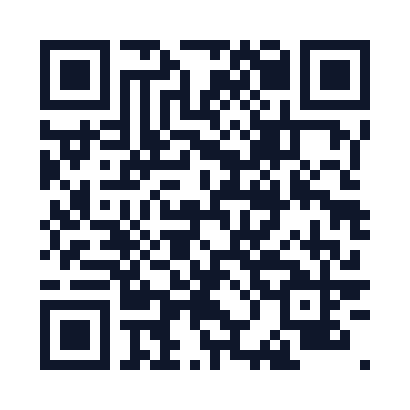

Pushed 2 files to GitHub!
Live at: https://worldstar0722.github.io/IS_Research_2025
GitHub Pages updates in ~30 seconds.


True

In [15]:
import qrcode, base64

PAGES_URL = f"https://{GITHUB_USERNAME}.github.io/{GITHUB_REPO}"

if GITHUB_USERNAME:
    qr = qrcode.QRCode(version=1, box_size=10, border=4)
    qr.add_data(PAGES_URL)
    qr.make(fit=True)
    img = qr.make_image(fill_color="#0f172a", back_color="white")
    img.save("docs/qr.png")

    with open("docs/qr.png", "rb") as f:
        qr_b64 = base64.b64encode(f.read()).decode()

    qr_block = (
        '<div style="display:flex;align-items:center;gap:2rem;'
        'padding:1.5rem 2.5rem;border-top:1px solid var(--border);background:var(--surface)">'
        '<img src="data:image/png;base64,' + qr_b64 + '" '
        'style="width:100px;height:100px;image-rendering:pixelated;'
        'border:4px solid white;border-radius:4px;flex-shrink:0"/>'
        '<div>'
        '<div style="font-family:var(--disp);font-size:.75rem;color:var(--accent);'
        'margin-bottom:.4rem;font-weight:700">Scan for live predictions</div>'
        f'<div style="font-size:.65rem;color:var(--muted);margin-bottom:.3rem">{PAGES_URL}</div>'
        '<div style="font-size:.6rem;color:var(--muted);opacity:.6">'
        'Updated daily · S&P 500 ML Research Pipeline</div>'
        '</div></div>'
    )

    html = (DOCS / "index.html").read_text(encoding="utf-8")
    html = html.replace("</body>", qr_block + "\n</body>")
    (DOCS / "index.html").write_text(html, encoding="utf-8")
    print(f"QR code embedded.")
    print(f"Live URL: {PAGES_URL}")

    from IPython.display import display, Image as IImage
    display(IImage("docs/qr.png"))
else:
    print("Set GITHUB_USERNAME in Section 2.")


def push_to_github(token: str, username: str, repo: str) -> bool:
    """Push all files in docs/ to the GitHub repo. Pages serves from /docs."""
    if not token or not username:
        print("GITHUB_TOKEN or GITHUB_USERNAME not set.")
        return False

    base = f"https://api.github.com/repos/{username}/{repo}/contents"
    hdrs = {
        "Authorization": f"token {token}",
        "Accept": "application/vnd.github.v3+json",
    }

    pushed = 0
    for f in DOCS.glob("*"):
        if not f.is_file(): continue
        with open(f, "rb") as fh:
            content = base64.b64encode(fh.read()).decode()

        api_url = f"{base}/docs/{f.name}"
        sha     = None
        r = requests.get(api_url, headers=hdrs)
        if r.status_code == 200:
            sha = r.json().get("sha")

        payload = {"message": f"Auto-update predictions {TODAY}", "content": content}
        if sha:
            payload["sha"] = sha

        r = requests.put(api_url, headers=hdrs, json=payload)
        if r.status_code in [200, 201]:
            pushed += 1
        else:
            print(f"  Failed: {f.name} ({r.status_code})")

    if pushed:
        print(f"Pushed {pushed} files to GitHub!")
        print(f"Live at: {PAGES_URL}")
        print("GitHub Pages updates in ~30 seconds.")
        return True
    return False

push_to_github(GITHUB_TOKEN, GITHUB_USERNAME, GITHUB_REPO)

## Section 13 — GitHub Actions (Automated Daily Updates)

In [17]:
WORKFLOW = """
name: Daily S&P 500 Research Pipeline

on:
  schedule:
    - cron: "0 13 * * 1-5"   # 9am ET, Mon-Fri only
  workflow_dispatch:           # allow manual trigger from GitHub UI

permissions:
  contents: write

jobs:
  predict:
    runs-on: ubuntu-latest
    timeout-minutes: 120

    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install yfinance lightgbm scikit-learn pandas numpy tqdm matplotlib \\
                      joblib "qrcode[pil]" requests feedparser \\
                      beautifulsoup4 lxml ta optuna transformers torch accelerate

      - name: Run pipeline
        run: python pipeline.py
        env:
          PYTHONUNBUFFERED: 1
          GITHUB_TOKEN: ${{ secrets.GITHUB_TOKEN }}
          GITHUB_USERNAME: ${{ github.repository_owner }}
          GITHUB_REPO: ${{ github.event.repository.name }}

      - name: Push updated predictions to GitHub Pages
        run: |
          git config user.email "actions@github.com"
          git config user.name  "GitHub Actions"
          git add docs/ predictions/ models/
          git diff --staged --quiet || (
            git commit -m "Daily update $(date +%Y-%m-%d)" && git push
          )
"""
print(WORKFLOW)
print("=" * 55)
print("Setup steps:")
print("  1. Create .github/workflows/daily.yml in your repo")
print("     and paste the YAML above")
print("  2. Settings > Pages > Branch: main > Folder: /docs")
print(f"  3. Your site: https://{GITHUB_USERNAME}.github.io/{GITHUB_REPO}")
print()
print("  Predictions update automatically every weekday at 9am ET.")


name: Daily S&P 500 Research Pipeline

on:
  schedule:
    - cron: "0 13 * * 1-5"   # 9am ET, Mon-Fri only
  workflow_dispatch:           # allow manual trigger from GitHub UI

permissions:
  contents: write

jobs:
  predict:
    runs-on: ubuntu-latest
    timeout-minutes: 120

    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: |
          pip install yfinance lightgbm scikit-learn pandas numpy tqdm matplotlib \
                      joblib "qrcode[pil]" requests feedparser \
                      beautifulsoup4 lxml ta optuna transformers torch accelerate

      - name: Run pipeline
        run: python pipeline.py
        env:
          PYTHONUNBUFFERED: 1
          GITHUB_TOKEN: ${{ secrets.GITHUB_TOKEN }}
          GITHUB_USERNAME: ${{ github.repository_owner }}
          GITHUB_REPO: ${{ github.event.repository.name }}

      - name: Push updated predict